## Importaciones

In [1]:
!pip install kaggle


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install load_dotenv


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import json
import os
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, \
    RandomForestClassifier, RandomForestRegressor, ExtraTreesClassifier, BaggingClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.linear_model import LinearRegression, LogisticRegression, PassiveAggressiveClassifier, RidgeClassifier, \
    SGDClassifier
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

## Utilidades

In [4]:
def detect_environment():
    try:
        ipython_env = str(get_ipython())
        if 'google.colab' in ipython_env:
            return "colab"
        elif 'zmqshell' in ipython_env:
            return "jupyter"
        else:
            return "interactive"
    except NameError:
        return "script"

In [5]:
def setup_kaggle_credentials():
    env = detect_environment()

    if env == "colab":
        from google.colab import userdata
        try:
            os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
            os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
            print("Credenciales cargadas desde Secretos de Colab.")
        except Exception:
            print("Configura KAGGLE_USERNAME y KAGGLE_KEY en los secretos de Colab.")
    else:
        try:
            load_dotenv()
        except ImportError:
            print("'python-dotenv' no está instalado. Pasando a buscar kaggle.json...")

        if not os.environ.get('KAGGLE_USERNAME') and os.path.exists('kaggle.json'):
            with open('kaggle.json', 'r') as f:
                creds = json.load(f)
                os.environ['KAGGLE_USERNAME'] = creds['username']
                os.environ['KAGGLE_KEY'] = creds['key']
            print("Credenciales cargadas desde archivo kaggle.json local.")

        elif os.environ.get('KAGGLE_USERNAME') and os.environ.get('KAGGLE_KEY'):
            print("Credenciales cargadas desde variables de entorno.")

    if not os.environ.get('KAGGLE_USERNAME') or not os.environ.get('KAGGLE_KEY'):
        print("No se encontraron credenciales reales. Cargando valores por defecto.")

        os.environ['KAGGLE_USERNAME'] = "default"
        os.environ['KAGGLE_KEY'] = "default"

In [6]:

def download_kaggle_dataset(dataset_slug, download_path="data"):
    os.makedirs(download_path, exist_ok=True)

    import kaggle

    print(f"Descargando '{dataset_slug}' en '{download_path}'...")
    kaggle.api.dataset_download_files(dataset_slug, path=download_path, unzip=False)

    dataset_name = dataset_slug.split('/')[-1]
    zip_path = os.path.join(download_path, f"{dataset_name}.zip")

    return zip_path

In [7]:
def extract_zip_file(zip_path, extract_to="data"):
    print(f"Descomprimiendo '{zip_path}'...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

    return extract_to

In [8]:
def get_dataset(dataset_slug, target_file, data_dir="data"):
    os.makedirs(data_dir, exist_ok=True)
    target_path = os.path.join(data_dir, target_file)

    if os.path.exists(target_path):
        print(f"El archivo '{target_path}' ya existe. Omitiendo descarga.")
        return target_path

    zip_path = download_kaggle_dataset(dataset_slug, download_path=data_dir)
    extract_zip_file(zip_path, extract_to=data_dir)

    if os.path.exists(zip_path):
        os.remove(zip_path)

    print(f"Proceso completado. Datos listos en: {target_path}")
    return target_path

## Dataframe

In [9]:
setup_kaggle_credentials()

Credenciales cargadas desde variables de entorno.


In [10]:
DATASET_SLUG = 'yasserh/housing-prices-dataset'
TARGET_FILENAME = 'Housing.csv'
DATA_DIRECTORY = 'dataset_housing'

In [11]:
csv_path = get_dataset(
    dataset_slug=DATASET_SLUG,
    target_file=TARGET_FILENAME,
    data_dir=DATA_DIRECTORY
)

El archivo 'dataset_housing\Housing.csv' ya existe. Omitiendo descarga.


In [12]:
df = pd.read_csv(csv_path)
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [13]:
print(f"Dimensiones del dataset: {df.shape}")

Dimensiones del dataset: (545, 13)


In [14]:
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [15]:
df.sample(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
331,3920000,7260,3,2,1,yes,yes,yes,no,no,3,no,furnished
400,3500000,3512,2,1,1,yes,no,no,no,no,1,yes,unfurnished
491,2835000,2640,2,1,1,no,no,no,no,no,1,no,furnished
218,4830000,4815,2,1,1,yes,no,no,no,yes,0,yes,semi-furnished
158,5495000,7980,3,1,1,yes,no,no,no,no,2,no,semi-furnished


In [16]:
df.describe(include='all')

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545,545,545,545,545,545.000000,545,545
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN,2,3
top,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,NaN,no,semi-furnished
freq,NaN,NaN,NaN,NaN,NaN,468,448,354,520,373,NaN,417,227
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,NaN,NaN,NaN,NaN,NaN,0.693578,NaN,NaN
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,NaN,NaN,NaN,NaN,NaN,0.861586,NaN,NaN
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [18]:
df_num = df.select_dtypes(include=['int64', 'float64'])
df_num

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2
...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2
541,1767150,2400,3,1,1,0
542,1750000,3620,2,1,1,0
543,1750000,2910,3,1,1,0


In [19]:
df_num.head(5)

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2


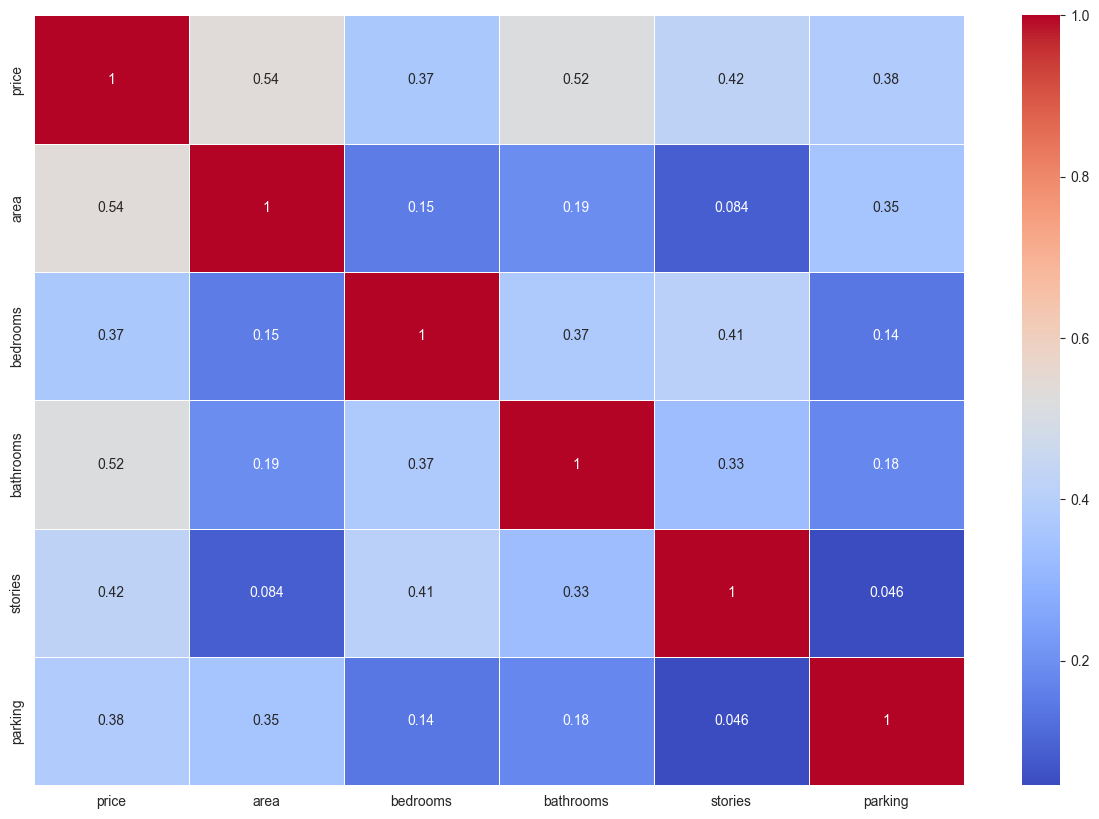

In [20]:
plt.figure(figsize=(15, 10))
sns.heatmap(df_num.corr(), cmap='coolwarm', linewidths=0.5, annot=True)
plt.show()

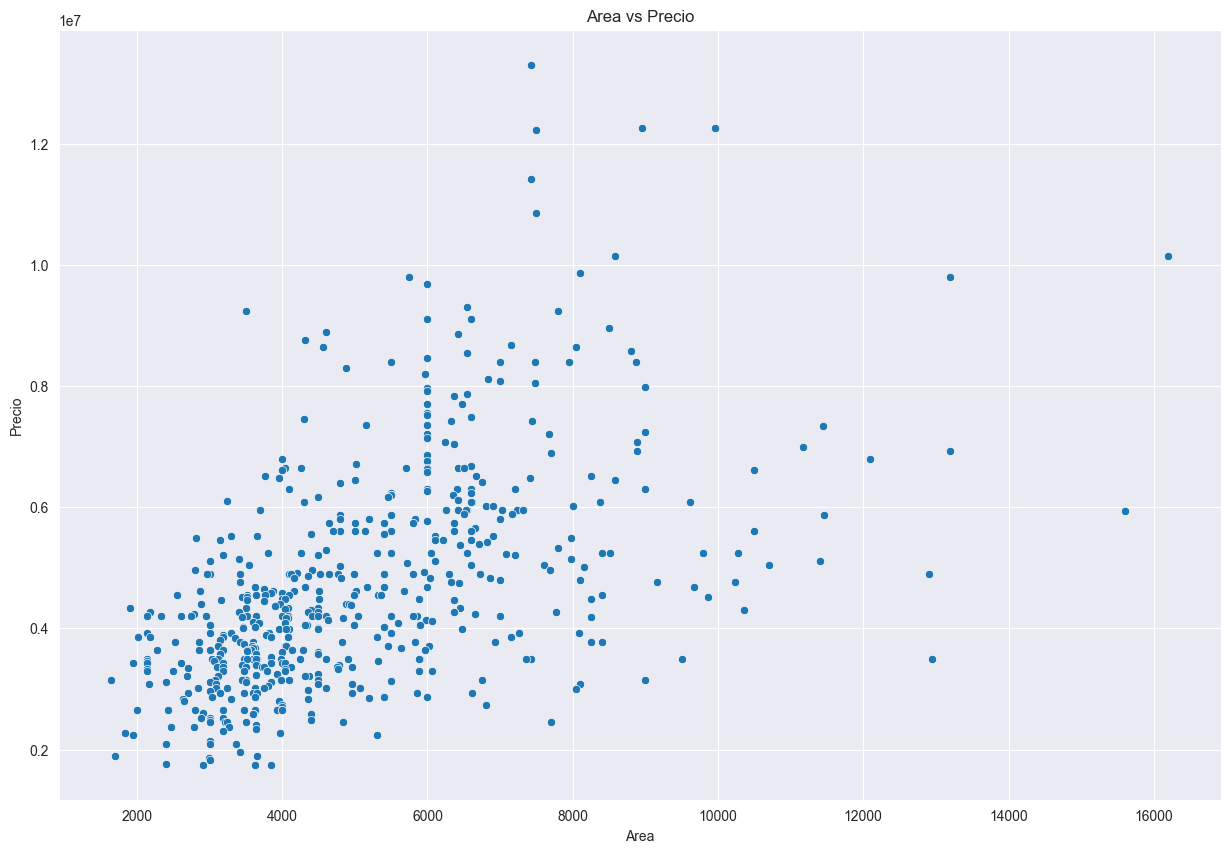

In [21]:
plt.figure(figsize=(15, 10))
sns.scatterplot(data=df, x='area', y='price')
plt.title('Area vs Precio')
plt.xlabel('Area')
plt.ylabel('Precio')
plt.show()

In [22]:
columns_to_encode = [
    'mainroad', 'guestroom', 'basement', 'hotwaterheating',
    'airconditioning', 'prefarea', 'furnishingstatus', 'parking'
]

In [23]:
df_encode = pd.get_dummies(df, columns=columns_to_encode)

In [24]:
df_encode.dtypes

price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad_no                         bool
mainroad_yes                        bool
guestroom_no                        bool
guestroom_yes                       bool
basement_no                         bool
basement_yes                        bool
hotwaterheating_no                  bool
hotwaterheating_yes                 bool
airconditioning_no                  bool
airconditioning_yes                 bool
prefarea_no                         bool
prefarea_yes                        bool
furnishingstatus_furnished          bool
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
parking_0                           bool
parking_1                           bool
parking_2                           bool
parking_3                           bool
dtype: object

In [25]:
X = df_encode.drop('price', axis=1)
X

,area,bedrooms,bathrooms,stories,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,basement_no,basement_yes,...,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,parking_0,parking_1,parking_2,parking_3
0,7420,4,2,3,False,True,True,False,True,False,...,True,False,True,True,False,False,False,False,True,False
1,8960,4,4,4,False,True,True,False,True,False,...,True,True,False,True,False,False,False,False,False,True
2,9960,3,2,2,False,True,True,False,False,True,...,False,False,True,False,True,False,False,False,True,False
3,7500,4,2,2,False,True,True,False,False,True,...,True,False,True,True,False,False,False,False,False,True
4,7420,4,1,2,False,True,False,True,False,True,...,True,True,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,False,True,True,False,False,True,...,False,True,False,False,False,True,False,False,True,False
541,2400,3,1,1,True,False,True,False,True,False,...,False,True,False,False,True,False,True,False,False,False
542,3620,2,1,1,False,True,True,False,True,False,...,False,True,False,False,False,True,True,False,False,False
543,2910,3,1,1,True,False,True,False,True,False,...,False,True,False,True,False,False,True,False,False,False


In [26]:
y = df_encode['price']
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
y_pred = model.predict(X_test_scaled)
print(y_pred)

[5218687.60025707 7208085.56255914 3096511.60517922 4597876.58326064
 3283282.33281424 3522775.84154755 5606750.38925575 6353641.16913224
 2769690.85368377 2614414.20399504 9609063.12794882 2788533.02840102
 3156902.95200242 3379379.57602391 3673456.59157602 5244530.76192836
 3022128.21895675 4840388.78011504 4406035.05268188 3557612.20911668
 5761118.93402921 5870852.08053913 2721485.23650195 4780838.00859879
 5090056.29822213 7550238.7879527  3208646.04165121 5176158.21767522
 8135882.281671   3384153.54917086 6479734.94403118 3371692.30543867
 6686527.51462784 4186653.17730818 3549562.9596983  5888587.55783594
 4801646.34679057 4357586.95132737 3179262.89396796 4586201.4762799
 4561781.65434032 3508176.2770892  7189265.12974536 4035579.5717665
 3734053.76674581 4328975.51700962 6738722.14315234 4091143.27260717
 3756844.29666968 3420442.44544927 7262224.86253223 2859102.76528239
 4391082.49514554 4499898.04364546 3674643.54662606 2663817.84013119
 7544241.62406139 2912010.12013253 4

In [31]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R2: {r2}')

MSE: 1739553620722.7537
RMSE: 1318921.385345902
R2: 0.6558453961589379


# Evaluación de Modelos

In [32]:
modelos = {
    'Random Forest Regresor': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=20),
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
}

In [33]:
def metrics(model, x_test_scaled, y_test):
    y_pred = model.predict(x_test_scaled)
    print(y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f'MSE: {mse}')
    print(f'RMSE: {rmse}')
    print(f'R2: {r2}')

In [35]:
for nombre, modelo in modelos.items():
    print(f"=========================================")
    print(f"Entrenando y evaluando: {nombre}")
    print(f"=========================================")
    modelo.fit(X_train_scaled, y_train)
    metrics(modelo, X_test_scaled, y_test)
    print("\n")

Entrenando y evaluando: Random Forest Regresor
[5653900.         7281680.         3791068.75       4540340.
 3789730.         3499020.         5053020.         5038740.
 2551150.         2871519.         9916544.4        3352539.16666667
 2973156.66666667 3462620.         3616900.         3821510.
 3331471.5        5058690.         3663905.         3963645.
 5490975.         5871250.         3081901.66666667 3726800.
 4823700.         6472130.         3069150.         4560220.
 6635580.         3297420.         5455835.         3199070.
 6739909.4        4290090.         2941120.         6584340.
 4803120.         3644655.         3103730.         4288585.
 3886750.         2807490.         7345310.         4190690.
 3919720.         4422250.         7231239.4        4140640.
 3056690.         3101770.         8100940.4        2559830.
 4093390.         4518640.         3275731.66666667 2865887.5
 7143535.         3004400.         4996880.         3119853.33333333
 4091010.         359